# Mutual Funds Analysis

## Project Overview

This notebook analyzes mutual fund data using Python.

The project covers data cleaning, exploratory data analysis, statistics, data visualization, correlation, and basic regression.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load the cleaned mutual fund dataset

df = pd.read_csv("../data/processed/cleaned_fund_master.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (40, 15)


In [4]:
# Display the first 5 rows
print("===== FIRST 5 ROWS =====")
display(df.head())

# Display dataset information
print("\n===== DATASET INFORMATION =====")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Display column names
print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

# Display data types
print("\n===== DATA TYPES =====")
print(df.dtypes)

===== FIRST 5 ROWS =====


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02



===== DATASET INFORMATION =====
Rows: 40
Columns: 15

===== COLUMN NAMES =====
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

===== DATA TYPES =====
amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager              str
risk_category             str
sebi_category_code        str
dtype: object


In [7]:
# ===== BASIC STATISTICS =====

print("===== MEAN =====")

mean_expense = df["expense_ratio_pct"].mean()
mean_exit_load = df["exit_load_pct"].mean()

print("Mean Expense Ratio:", round(mean_expense, 2))
print("Mean Exit Load:", round(mean_exit_load, 2))


print("\n===== MEDIAN =====")

median_expense = df["expense_ratio_pct"].median()
median_exit_load = df["exit_load_pct"].median()

print("Median Expense Ratio:", round(median_expense, 2))
print("Median Exit Load:", round(median_exit_load, 2))


print("\n===== MODE =====")

mode_expense = df["expense_ratio_pct"].mode()
mode_exit_load = df["exit_load_pct"].mode()

print("Mode Expense Ratio:")
print(mode_expense.tolist())

print("Mode Exit Load:")
print(mode_exit_load.tolist())

===== MEAN =====
Mean Expense Ratio: 1.24
Mean Exit Load: 0.81

===== MEDIAN =====
Median Expense Ratio: 1.42
Median Exit Load: 1.0

===== MODE =====
Mode Expense Ratio:
[1.38]
Mode Exit Load:
[1.0]


In [8]:
# ===== STANDARD DEVIATION =====

print("===== STANDARD DEVIATION =====")

std_expense = df["expense_ratio_pct"].std()
std_exit_load = df["exit_load_pct"].std()

print("Expense Ratio Standard Deviation:", round(std_expense, 2))
print("Exit Load Standard Deviation:", round(std_exit_load, 2))

===== STANDARD DEVIATION =====
Expense Ratio Standard Deviation: 0.39
Exit Load Standard Deviation: 0.39


In [9]:
# ===== CORRELATION ANALYSIS =====

print("===== CORRELATION MATRIX =====")

correlation = df[
    ["expense_ratio_pct", "exit_load_pct"]
].corr()

print(correlation)

===== CORRELATION MATRIX =====
                   expense_ratio_pct  exit_load_pct
expense_ratio_pct           1.000000       0.529036
exit_load_pct               0.529036       1.000000


In [10]:
# ===== PROBABILITY BASICS =====

print("===== PROBABILITY =====")

average_expense = df["expense_ratio_pct"].mean()

above_average = df[
    df["expense_ratio_pct"] > average_expense
]

total_schemes = len(df)
above_average_schemes = len(above_average)

probability = above_average_schemes / total_schemes

print("Total Schemes:", total_schemes)
print("Schemes Above Average Expense Ratio:", above_average_schemes)
print("Probability:", round(probability, 2))
print("Probability (%):", round(probability * 100, 2), "%")

===== PROBABILITY =====
Total Schemes: 40
Schemes Above Average Expense Ratio: 26
Probability: 0.65
Probability (%): 65.0 %


In [11]:
# ===== SIMPLE LINEAR REGRESSION =====

print("===== REGRESSION =====")

x = df["expense_ratio_pct"]
y = df["exit_load_pct"]

# Calculate slope and intercept
slope, intercept = np.polyfit(x, y, 1)

print("Slope:", round(slope, 4))
print("Intercept:", round(intercept, 4))

print(
    "Regression Equation:"
    f" Exit Load = {slope:.4f} × Expense Ratio + {intercept:.4f}"
)

===== REGRESSION =====
Slope: 0.5297
Intercept: 0.1572
Regression Equation: Exit Load = 0.5297 × Expense Ratio + 0.1572


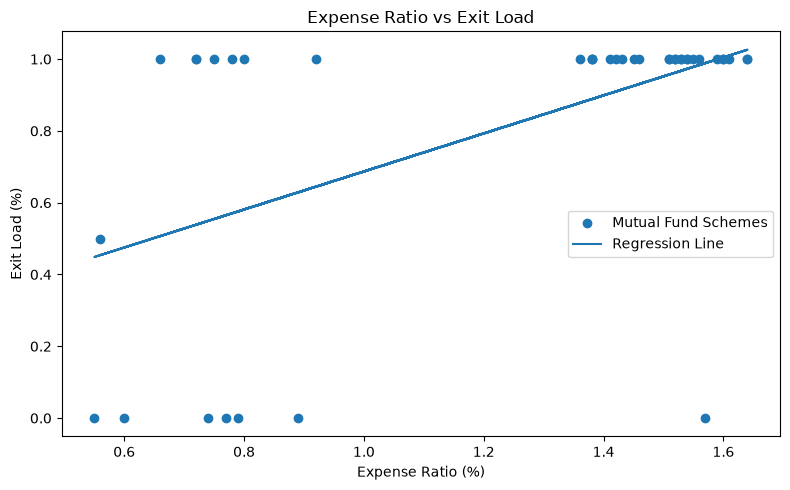

In [13]:
# ===== REGRESSION VISUALIZATION =====

plt.figure(figsize=(8, 5))

plt.scatter(
    df["expense_ratio_pct"],
    df["exit_load_pct"],
    label="Mutual Fund Schemes"
)

# Regression line
x = df["expense_ratio_pct"]
y_pred = slope * x + intercept

plt.plot(
    x,
    y_pred,
    label="Regression Line"
)

plt.title("Expense Ratio vs Exit Load")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Exit Load (%)")
plt.legend()

plt.tight_layout()
plt.show()

## Business Insights

Based on the analysis of the mutual fund data:

- The mean and median help understand the typical expense ratio and exit load of the schemes.
- Standard deviation shows how much expense ratios and exit loads vary between schemes.
- Correlation helps understand whether expense ratio and exit load have a relationship.
- Probability analysis shows the chance of randomly selecting a scheme with an above-average expense ratio.
- Regression provides an initial understanding of whether expense ratio can be used to estimate exit load.
- The visualizations make it easier to understand patterns and relationships in the mutual fund data.

## Conclusion

The analysis provided a basic statistical understanding of the mutual fund dataset.

Mean, median, mode, standard deviation, correlation, probability, and regression were applied using Python. These techniques helped identify patterns, variation, and relationships within the data.

The analysis can be used as a starting point for deeper mutual fund performance and investment analysis.